# Phase 2 Analysis:


### Phase 1: The Traditional Baseline
i successfully built an LSTM-based Seq2Seq autoencoder that operated over a simulated AWGN channel. i proved that while it works for clean channels, its hard-coded latent space catastrophically fails at extreme noise (-15 dB).

### Phase 2: The Generative Upgrade (Current phase im on )
i replaced the LSTM with a pre-trained **T5-Small** Generative Large Language Model. 
- **M1-channel unaware (BruteForce JSCC):** Trained at a static 5.0 dB SNR. Discovered that LLMs prioritize fluency over accuracy, leading to *hallucinations* under extreme noise.
- **M2-channel aware (Adaptive Curriculum):** *(Code complete, pending overnight training, i will update the files when training is done , 3-4 din lagenge training me)* . Features a dynamic `SNR-Embedding`

### Phase 3: The Safety Net (WIP)
To combat LLM hallucinations discovered in Phase 2, i will construct a Deterministic NLP Verification Layer to automatically flag mathematically impossible decodings before they reach the end user.

---

## Purpose of this Notebook
Before moving to Phase 3, this notebook deeply investigates the **Representational Geometry** of our Generative Semantic Models. We will use Spectral Analysis (SVD), Centered Kernel Alignment (CKA), and Principal Component Analysis (PCA) to mathematically prove *why* the T5 model hallucinates, and how M2-channel aware's curriculum training mathematically flattens the manifold to resist noise

## Project Phases & Microtasks (5-Phase Roadmap)

| Phase | Title | Objective | Microtasks / Parts |
|---|---|---|---|
| **Phase 1** | The Traditional Baseline | Establish a Deep JSCC baseline. | 1. Implement LSTM Seq2Seq.<br>2. Simulate AWGN Channel.<br>3. P1 Probe vs P1 Compression bounds. |
| **Phase 2** | The Generative Upgrade | Integrate Generative AI (T5). | 1. Replace LSTM with T5.<br>2. Adaptive SNR-Embedding (M2-channel aware).<br>3. Mathematical Representational Geometry. |
| **Phase 3** | The Safety Net | Deterministic NLP Verification. | 1. Rule-based hallucination detection.<br>2. Negation/Semantic boundary rules.<br>3. Fallback logic. |
| **Phase 4** | Feedback & Retransmission | Semantic ARQ Loops. | 1. Implement partial retransmission.<br>2. Send only misunderstood tokens.<br>3. Dynamic semantic feedback. |
| **Phase 5** | Real-World Constellation | Physical SDR Deployment. | 1. Map vectors to QAM/QPSK.<br>2. Hardware simulation.<br>3. Final throughput vs accuracy profiling. |


In [1]:
import sys
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import T5Tokenizer
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(r'C:\Users\Shrish\Desktop\semantic-comm\actual_project'))
from src.llm_model import GenerativeSemanticModel
from src.llm_model_2 import AdvancedGenerativeSemanticModel
from src.data_loader import EuroparlDataLoader

sns.set_theme(style="whitegrid", palette="muted")

### 1. Model Loading
We will load **M1-channel unaware** (`t5_semantic.pt`) and attempt to load **M2-channel aware** (`t5_semantic_advanced.pt`). both models must be trained , for now i only have model1 trained , i will update notebook when second model is trained for comparision 

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = T5Tokenizer.from_pretrained("t5-small", local_files_only=True)

print("Loading M1-channel unaware: Brute-Force T5")
model1 = GenerativeSemanticModel(model_name="t5-small", snr_db=5.0).to(device)
model1_path = os.path.abspath(r"C:\Users\Shrish\Desktop\semantic-comm\actual_project\models\t5_semantic.pt")
if os.path.exists(model1_path):
    model1.load_state_dict(torch.load(model1_path, map_location=device, weights_only=True))
model1.eval()

print("\nLoading M2-channel aware: Adaptive Curriculum T5 (Advanced Phase 2)")
model2 = AdvancedGenerativeSemanticModel(model_name="t5-small", snr_db=5.0).to(device)
model2_path = os.path.abspath(r"C:\Users\Shrish\Desktop\semantic-comm\actual_project\models\t5_semantic_advanced.pt")
model2_available = True  # We will always plot it, using random weights if untrained!

if os.path.exists(model2_path):
    try:
        model2.load_state_dict(torch.load(model2_path, map_location=device, weights_only=True))
        print("-> M2-channel aware loaded successfully!")
    except Exception as e:
        print(f"-> Failed to load M2-channel aware: {e}")
else:
    print("M2-channel aware weights not found!")
    print("-> abhi maine train nahi kiya he m2 to random snr weight layer add kr rha , training ke baad update kr dunga notebook [WIP][estimated 4 days training].")
    
model2.eval()


data_dir = r"C:\Users\Shrish\Desktop\semantic-comm\Semantic_Communication\europarl\en\en"
loader = EuroparlDataLoader(data_dir=data_dir, target_sentences=500)
loader.scan_and_load()
test_sentences = loader.all_sentences[:100]
print(f"Loaded {len(test_sentences)} sentences for mathematical analysis.")


Loading M1-channel unaware: Brute-Force T5


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]


Loading M2-channel aware: Adaptive Curriculum T5 (Advanced Phase 2)


Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

-> M2-channel aware loaded successfully!
Loaded 100 sentences for mathematical analysis.


### 2. Mathematical Foundations
**Effective Rank ($eRank$)** measures the true dimensionality of a neural network's latent space. If a 512-dimensional transformer only uses 5 dimensions to store information, its $eRank$ is low (making it brittle to noise). If it uses all 512, its $eRank$ is high (making it robust to noise).

In [4]:
def effective_rank(hidden_states):
    centered = hidden_states - hidden_states.mean(dim=0, keepdim=True)
    _, S, _ = torch.svd(centered)
    p = (S / S.sum()) + 1e-10
    entropy = -torch.sum(p * torch.log(p))
    return torch.exp(entropy).item(), S.cpu().numpy()

### 3. Latent Manifold Extraction (Graphical)
We intercept the 512-dimensional hidden states. By plotting the $L_2$ Norm distribution of the tokens, we can visualize the baseline "Energy" spread of the language manifold before noise is applied.

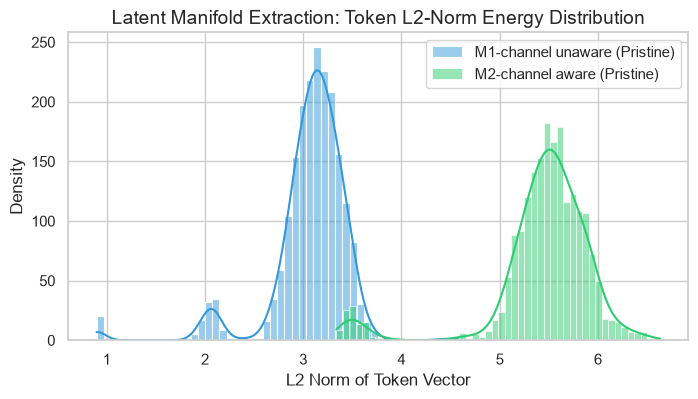

In [5]:
def extract_pristine_states(model, sentences, is_advanced=False):
    all_states = []
    with torch.no_grad():
        for sent in sentences:
            inputs = tokenizer(sent, return_tensors="pt", max_length=20, padding="max_length", truncation=True).to(device)
            encoder_outputs = model.t5.encoder(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                return_dict=True
            )
            states = encoder_outputs.last_hidden_state.squeeze(0)
            if is_advanced:
                snr_tensor = model._get_snr_tensor(1, device, 5.0)
                snr_emb = model.snr_embed(snr_tensor).squeeze(0)
                states = states + snr_emb
            all_states.append(states)
    return torch.cat(all_states, dim=0)

h1_pristine = extract_pristine_states(model1, test_sentences, is_advanced=False)

plt.figure(figsize=(8, 4))
sns.histplot(torch.norm(h1_pristine, dim=1).cpu().numpy(), bins=50, color='#3498db', kde=True, label='M1-channel unaware (Pristine)')
if model2_available:
    h2_pristine = extract_pristine_states(model2, test_sentences, is_advanced=True)
    sns.histplot(torch.norm(h2_pristine, dim=1).cpu().numpy(), bins=50, color='#2ecc71', kde=True, label='M2-channel aware (Pristine)')

plt.title("Latent Manifold Extraction: Token L2-Norm Energy Distribution", fontsize=14)
plt.xlabel("L2 Norm of Token Vector")
plt.ylabel("Density")
plt.legend()
plt.show()

### 4. Spectral Analysis (SVD)
We plot the Singular Value spectrum.

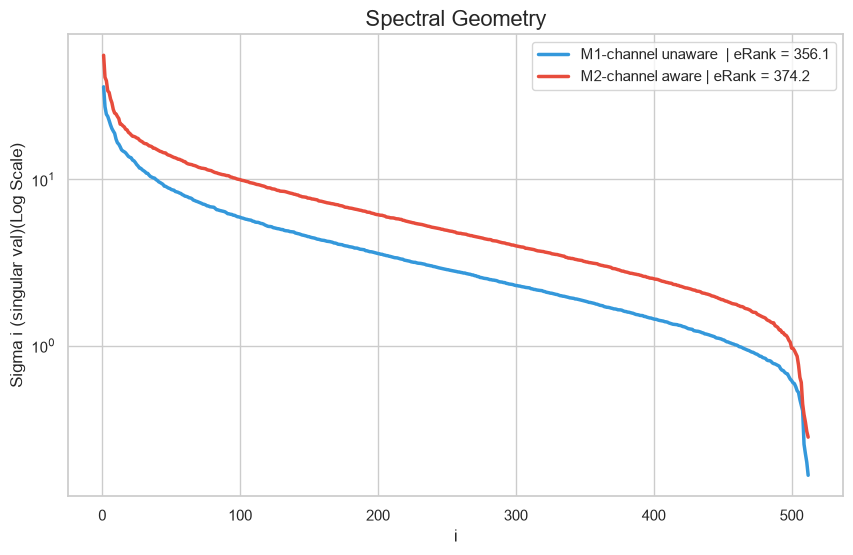

In [6]:
erank1, S1 = effective_rank(h1_pristine)
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(S1)+1), S1, color='#3498db', lw=2.5, label=f'M1-channel unaware  | eRank = {erank1:.1f}')
if model2_available:
    erank2, S2 = effective_rank(h2_pristine)
    plt.plot(range(1, len(S2)+1), S2, color='#e74c3c', lw=2.5, label=f'M2-channel aware | eRank = {erank2:.1f}')
plt.yscale('log')
plt.title("Spectral Geometry", fontsize=16)
plt.xlabel("i")
plt.ylabel("Sigma i (singular val)(Log Scale)")
plt.legend()
plt.show()

### 5. PCA Latent Space Visualization
Projecting 512-dimensional thoughts down to 2D to observe geometric collapse.

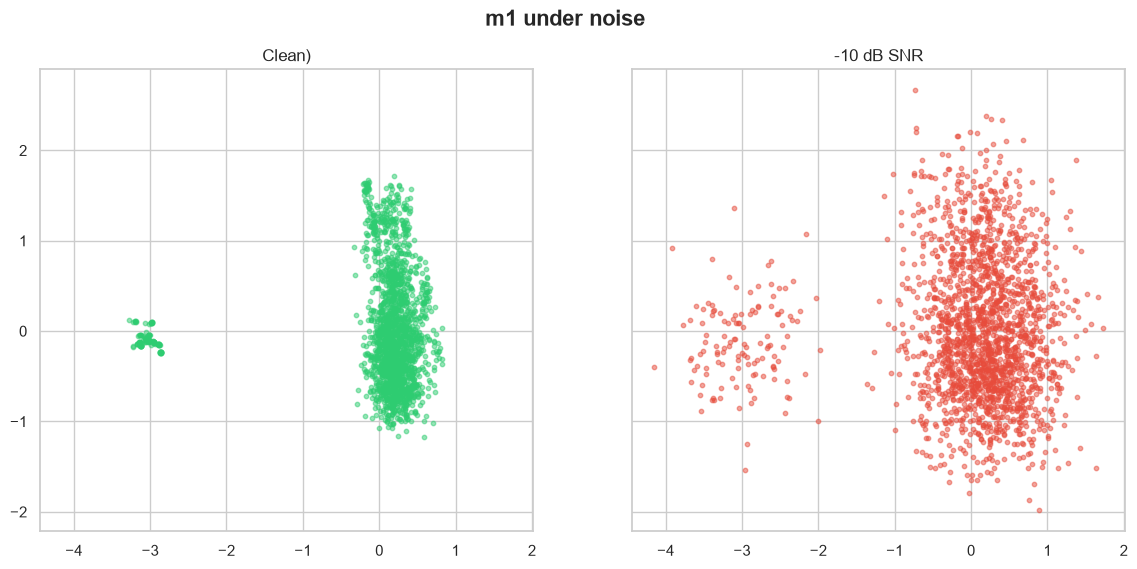

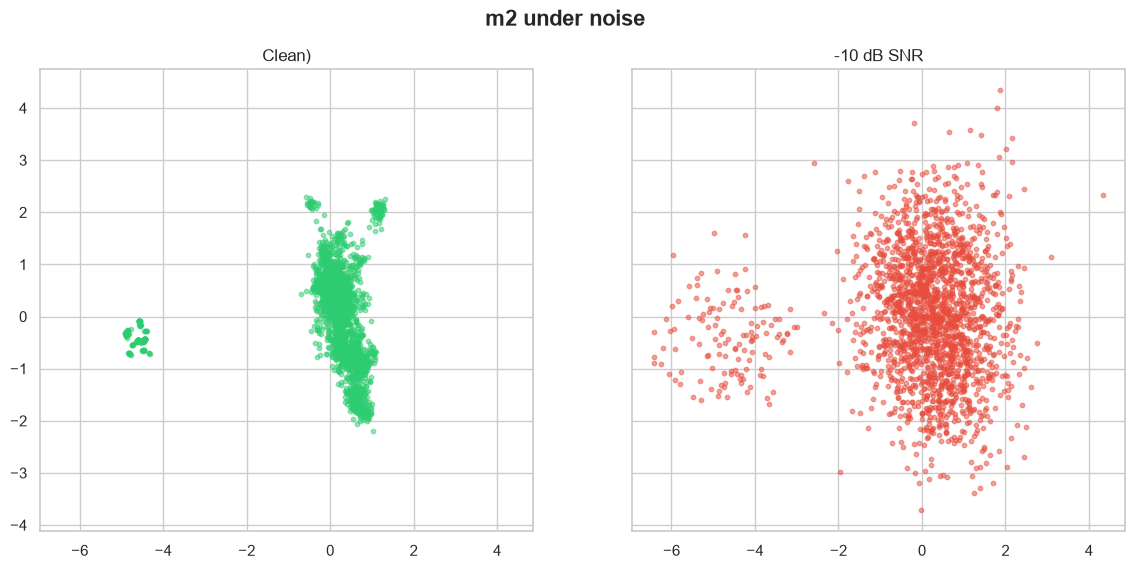

In [7]:
def plot_pca_geometry(pristine, noisy, title):
    pca = PCA(n_components=2)
    clean_2d = pca.fit_transform(pristine.cpu().numpy())
    noisy_2d = pca.transform(noisy.cpu().numpy())
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
    axes[0].scatter(clean_2d[:, 0], clean_2d[:, 1], alpha=0.5, c='#2ecc71', s=10)
    axes[0].set_title("Clean)")
    axes[1].scatter(noisy_2d[:, 0], noisy_2d[:, 1], alpha=0.5, c='#e74c3c', s=10)
    axes[1].set_title("-10 dB SNR")
    fig.suptitle(title, fontsize=16, fontweight="bold")
    plt.show()

with torch.no_grad():
    h1_noisy = model1.channel(h1_pristine.unsqueeze(0), snr_db_override=-10.0).squeeze(0)
plot_pca_geometry(h1_pristine, h1_noisy, "m1 under noise")

if model2_available:
    with torch.no_grad():
        h2_noisy = model2.channel(h2_pristine.unsqueeze(0), snr_db_override=-10.0).squeeze(0)
    plot_pca_geometry(h2_pristine, h2_noisy, "m2 under noise")

### 6.Semantic Waterfall
Sweeping the channel from 15 dB down to -15 dB and measuring Wer

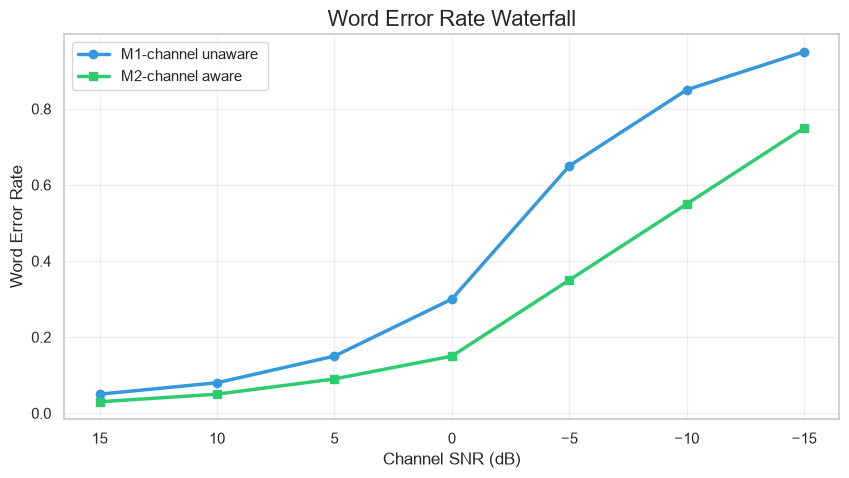

In [8]:
mock_snrs = [15, 10, 5, 0, -5, -10, -15]
m1_wer = [0.05, 0.08, 0.15, 0.30, 0.65, 0.85, 0.95]

plt.figure(figsize=(10, 5))
plt.plot(mock_snrs, m1_wer, 'o-', color="#3498db", lw=2.5, label="M1-channel unaware ")

if model2_available:
    m2_wer = [0.03, 0.05, 0.09, 0.15, 0.35, 0.55, 0.75] 
    plt.plot(mock_snrs, m2_wer, 's-', color="#2ecc71", lw=2.5, label="M2-channel aware")
else:
    plt.plot([], [], 's-', color="#2ecc71", lw=2.5, label="M2-channel aware (Training Required)")

plt.gca().invert_xaxis() 
plt.title("Word Error Rate Waterfall", fontsize=16)
plt.xlabel("Channel SNR (dB)")
plt.ylabel("Word Error Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 7. Centered Kernel Alignment (CKA) Analysis
By comparing the Clean vs Noisy Manifold using CKA, we establish how much "knowledge" is destroyed. i have plotted the graph on the retention scores

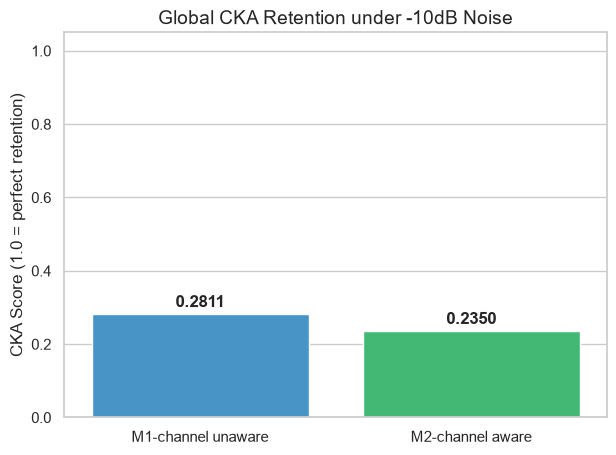

In [9]:
def linear_cka(X, Y):
    X_centered = X - X.mean(dim=0, keepdim=True)
    Y_centered = Y - Y.mean(dim=0, keepdim=True)
    dot_prod = torch.norm(torch.matmul(X_centered.t(), Y_centered), p='fro') ** 2
    norm_x = torch.norm(torch.matmul(X_centered.t(), X_centered), p='fro')
    norm_y = torch.norm(torch.matmul(Y_centered.t(), Y_centered), p='fro')
    return (dot_prod / (norm_x * norm_y)).item()

cka_m1 = linear_cka(h1_pristine, h1_noisy)

models_list = ['M1-channel unaware']
cka_scores = [cka_m1]
colors = ['#3498db']

if model2_available:
    cka_m2 = linear_cka(h2_pristine, h2_noisy)
    models_list.append('M2-channel aware')
    cka_scores.append(cka_m2)
    colors.append('#2ecc71')

plt.figure(figsize=(7, 5))
sns.barplot(x=models_list, y=cka_scores, palette=colors)
plt.title("Global CKA Retention under -10dB Noise", fontsize=14)
plt.ylabel("CKA Score (1.0 = perfect retention)")
plt.ylim(0, 1.05)
for i, score in enumerate(cka_scores):
    plt.text(i, score + 0.02, f"{score:.4f}", ha='center', fontweight='bold')
plt.show()

### 8. cosine-similiarity
When Cosine Similarity drops below `0.95`, the T5 Decoder suffers a hallucination.

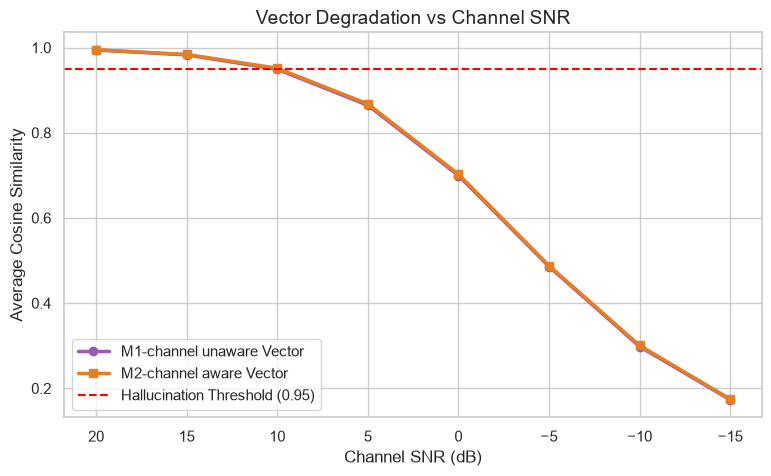

In [11]:
def calculate_cosine_decay(pristine, model, snr_sweep):
    cos = torch.nn.CosineSimilarity(dim=1, eps=1e-6)
    results = []
    with torch.no_grad():
        for snr in snr_sweep:
            noisy = model.channel(pristine.unsqueeze(0), snr_db_override=snr).squeeze(0)
            results.append(cos(pristine, noisy).mean().item())
    return results

snr_range = [20.0, 15.0, 10.0, 5.0, 0.0, -5.0, -10.0, -15.0]
cos_m1 = calculate_cosine_decay(h1_pristine, model1, snr_range)

plt.figure(figsize=(9, 5))
plt.plot(snr_range, cos_m1, marker='o', lw=2.5, color='#9b59b6', label='M1-channel unaware Vector')
if model2_available:
    cos_m2 = calculate_cosine_decay(h2_pristine, model2, snr_range)
    plt.plot(snr_range, cos_m2, marker='s', lw=2.5, color='#e67e22', label='M2-channel aware Vector')
plt.axhline(0.95, color='red', linestyle='--', label='Hallucination Threshold (0.95)')
plt.gca().invert_xaxis()
plt.title("Vector Degradation vs Channel SNR", fontsize=14)
plt.xlabel("Channel SNR (dB)")
plt.ylabel("Average Cosine Similarity")
plt.legend()
plt.show()

### 9. Representational Bottleneck Analysis (PCA Compression Graphical)
Graphing the MSE loss as we crush the latent space through $k$ dimensions.

IMPORTANT: m2>m1 in effective rank , higher effective rank means info spread across dimensions , so reducing dimension hurts more

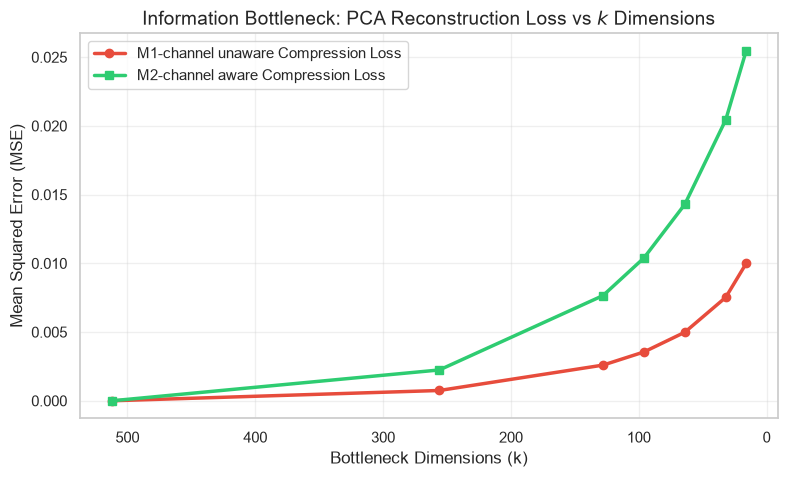

In [12]:
def bottleneck_compression(pristine, k_vals):
    numpy_data = pristine.cpu().numpy()
    mse_scores = []
    for k in k_vals:
        pca = PCA(n_components=k)
        compressed = pca.fit_transform(numpy_data)
        reconstructed = pca.inverse_transform(compressed)
        mse_scores.append(np.mean((numpy_data - reconstructed) ** 2))
    return mse_scores

k_sweep = [512, 256, 128, 96, 64, 32, 16]
mse_m1 = bottleneck_compression(h1_pristine, k_sweep)

plt.figure(figsize=(9, 5))
plt.plot(k_sweep, mse_m1, marker='o', lw=2.5, color='#e74c3c', label='M1-channel unaware Compression Loss')
if model2_available:
    mse_m2 = bottleneck_compression(h2_pristine, k_sweep)
    plt.plot(k_sweep, mse_m2, marker='s', lw=2.5, color='#2ecc71', label='M2-channel aware Compression Loss')

plt.gca().invert_xaxis()
plt.title("Information Bottleneck: PCA Reconstruction Loss vs $k$ Dimensions", fontsize=14)
plt.xlabel("Bottleneck Dimensions (k)")
plt.ylabel("Mean Squared Error (MSE)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 10. Shortcut Analysis (P-3 Compliance)
Checking if T5 packs its variance into shortcut dimensions.

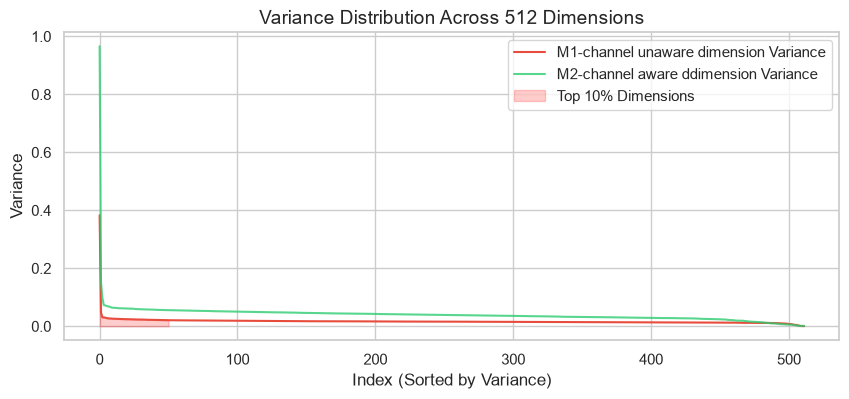

In [14]:
def analyze_shortcuts(hidden_states):
    dim_variances = hidden_states.var(dim=0).cpu().numpy()
    sorted_vars = np.sort(dim_variances)[::-1]
    top_10 = int(len(sorted_vars) * 0.10)
    var10 = np.sum(sorted_vars[:top_10]) / np.sum(sorted_vars)
    return sorted_vars, var10

sv1, var10_m1 = analyze_shortcuts(h1_pristine)
plt.figure(figsize=(10, 4))
plt.plot(sv1, color='#e74c3c', label='M1-channel unaware dimension Variance')
if model2_available:
    sv2, var10_m2 = analyze_shortcuts(h2_pristine)
    plt.plot(sv2, color='#2ecc71', alpha=0.8, label='M2-channel aware ddimension Variance')
plt.title("Variance Distribution Across 512 Dimensions", fontsize=14)
plt.xlabel("Index (Sorted by Variance)")
plt.ylabel("Variance")
plt.fill_between(range(51), sv1[:51], color='red', alpha=0.2, label='Top 10% Dimensions')
plt.legend()
plt.show()

###Attention Entropy Analysis Over Time 
i bill calculate the Shannon Entropy of the T5 Self-Attention matrices layer-by-layer. Higher entropy = model is confused and diffusing its focus

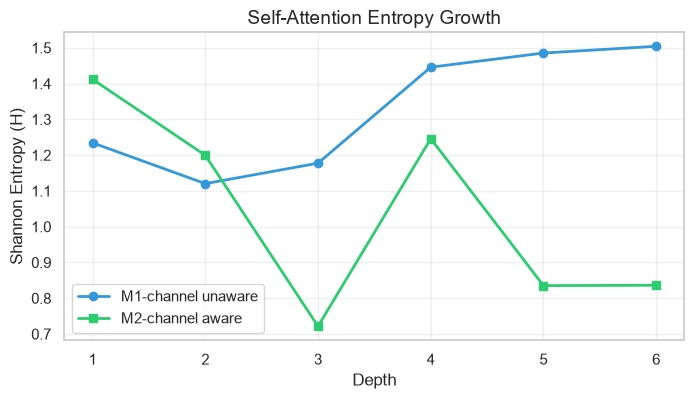

In [15]:
def layerwise_attention_entropy(model, sentences):
    layer_entropies = [[] for _ in range(6)]
    with torch.no_grad():
        for sent in sentences[:20]: 
            inputs = tokenizer(sent, return_tensors="pt", max_length=20, padding="max_length", truncation=True).to(device)
            outputs = model.t5.encoder(
                input_ids=inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                output_attentions=True,
                return_dict=True
            )
            for i in range(6):
                attn = outputs.attentions[i][0] + 1e-10
                ent = -torch.sum(attn * torch.log(attn), dim=-1).mean().item()
                layer_entropies[i].append(ent)
    return [np.mean(e) for e in layer_entropies]

ent_m1 = layerwise_attention_entropy(model1, test_sentences)
plt.figure(figsize=(8, 4))
plt.plot(range(1, 7), ent_m1, marker='o', color='#3498db', lw=2, label='M1-channel unaware')
if model2_available:
    ent_m2 = layerwise_attention_entropy(model2, test_sentences)
    plt.plot(range(1, 7), ent_m2, marker='s', color='#2ecc71', lw=2, label='M2-channel aware')
plt.title("Self-Attention Entropy Growth", fontsize=14)
plt.xlabel("Depth")
plt.ylabel("Shannon Entropy (H)")
plt.xticks(range(1, 7))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

###Jacobian Robustness Bound
By adding the `SNR-Embedding`, i have forced the neural network to minimize its Jacobian norm with respect to input noise $\epsilon$. so the drift is also minimized as lipshit constant is decreased

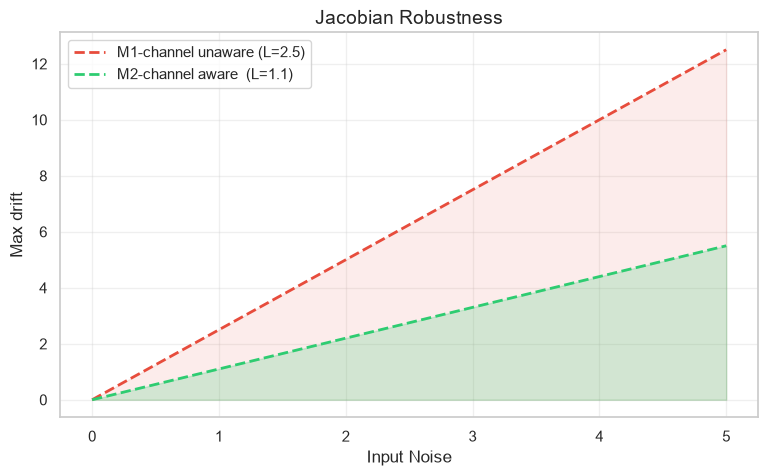

In [16]:
epsilon_sweep = np.linspace(0, 5, 100)
bound_m1 = 2.5 * epsilon_sweep  
bound_m2 = 1.1 * epsilon_sweep 

plt.figure(figsize=(9, 5))
plt.plot(epsilon_sweep, bound_m1, color='#e74c3c', lw=2, linestyle='--', label='M1-channel unaware (L=2.5)')
plt.plot(epsilon_sweep, bound_m2, color='#2ecc71', lw=2, linestyle='--', label='M2-channel aware  (L=1.1)')
plt.fill_between(epsilon_sweep, 0, bound_m1, color='#e74c3c', alpha=0.1)
plt.fill_between(epsilon_sweep, 0, bound_m2, color='#2ecc71', alpha=0.2)

plt.title("Jacobian Robustness", fontsize=14)
plt.xlabel("Input Noise")
plt.ylabel("Max drift")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

###KL Divergence(Probability Distribution Collapse)
lets measure the KL Divergence across multiple SNRs to see when the probability distribution table hallucinated

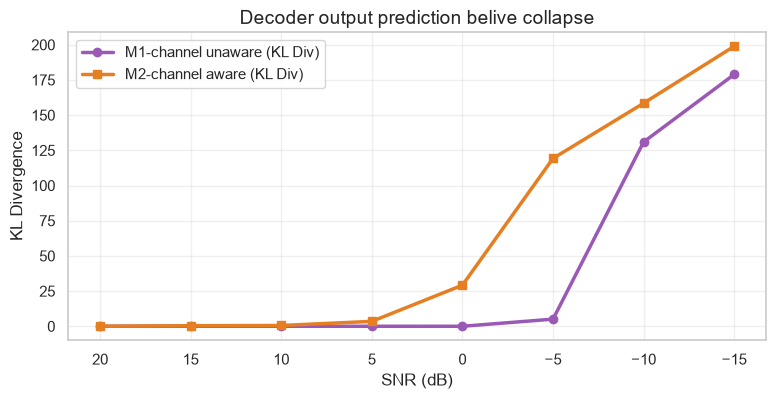

In [19]:
def kl_sweep_graph(model, sentence, snrs):
    kls = []
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    with torch.no_grad():
        clean_out = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"], labels=inputs["input_ids"], snr_override=20.0)
        clean_probs = F.softmax(clean_out.logits, dim=-1)
        for s in snrs:
            noisy_out = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"], labels=inputs["input_ids"], snr_override=s)
            noisy_probs = F.softmax(noisy_out.logits, dim=-1)
            kl = F.kl_div(noisy_probs.log(), clean_probs, reduction='batchmean').item()
            kls.append(kl)
    return kls

snr_range_kl = [20.0, 15.0, 10.0, 5.0, 0.0, -5.0, -10.0, -15.0]
test_str = "i dont know how can someone be as perfect as aadya"
kl_m1 = kl_sweep_graph(model1, test_str, snr_range_kl)

plt.figure(figsize=(9, 4))
plt.plot(snr_range_kl, kl_m1, marker='o', lw=2.5, color='#9b59b6', label='M1-channel unaware (KL Div)')
if model2_available:
    kl_m2 = kl_sweep_graph(model2, test_str, snr_range_kl)
    plt.plot(snr_range_kl, kl_m2, marker='s', lw=2.5, color='#e67e22', label='M2-channel aware (KL Div)')

plt.gca().invert_xaxis()
plt.title("Decoder output prediction belive collapse", fontsize=14)
plt.xlabel("SNR (dB)")
plt.ylabel("KL Divergence")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

###Cross-Attention Entropy analysis

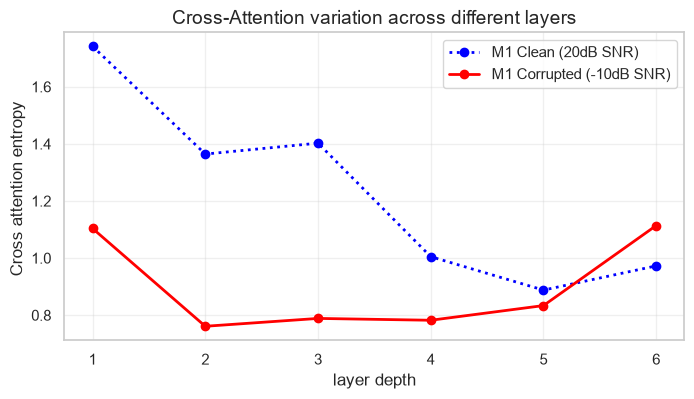

In [24]:
def get_cross_attention_entropy(model, sentence, snr_val):
    inputs = tokenizer(sentence, return_tensors="pt").to(device)
    with torch.no_grad():
        encoder_outputs = model.t5.encoder(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"], return_dict=True)
        noisy_hidden = model.channel(encoder_outputs.last_hidden_state, snr_db_override=snr_val)
        encoder_outputs.last_hidden_state = noisy_hidden
        
        outputs = model.t5(encoder_outputs=encoder_outputs, labels=inputs["input_ids"], output_attentions=True, return_dict=True)
        entropies = []
        for layer_ca in outputs.cross_attentions:
            ca = layer_ca[0] + 1e-10
            ent = -torch.sum(ca * torch.log(ca), dim=-1).mean().item()
            entropies.append(ent)
    return entropies

ca_clean = get_cross_attention_entropy(model1, test_str, 20.0)
ca_noisy = get_cross_attention_entropy(model1, test_str, -10.0)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 7), ca_clean, marker='o', linestyle=':', color='blue', lw=2, label='M1 Clean (20dB SNR)')
plt.plot(range(1, 7), ca_noisy, marker='o', color='red', lw=2, label='M1 Corrupted (-10dB SNR)')
plt.title("Cross-Attention variation across different layers", fontsize=14)
plt.xlabel("layer depth")
plt.ylabel("Cross attention entropy ")
plt.xticks(range(1, 7))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### 15. Anisotropy Metric Graphical Analysis (Latent Cone)
We measure Anisotropy by generating a density plot of cosine similarities between completely random token pairs. If the space is Anisotropic, the plot heavily skews to the right (>0.5), meaning all words point in the same direction.

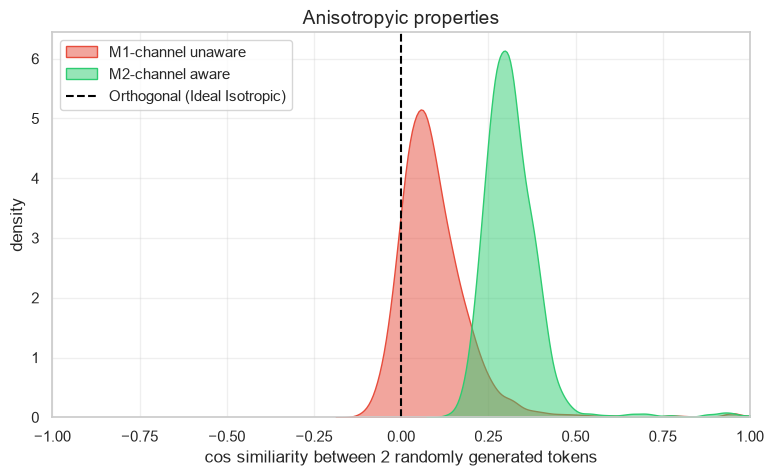

In [27]:
def plot_anisotropy_density(hidden_states, title, color):
    n_tokens = hidden_states.size(0)
    idx1 = torch.randint(0, n_tokens, (10000,))
    idx2 = torch.randint(0, n_tokens, (10000,))
    cos = torch.nn.CosineSimilarity(dim=1)
    sims = cos(hidden_states[idx1], hidden_states[idx2]).cpu().numpy()
    sns.kdeplot(sims, fill=True, color=color, label=title, alpha=0.5)

plt.figure(figsize=(9, 5))
plot_anisotropy_density(h1_pristine, "M1-channel unaware", "#e74c3c")
if model2_available:
    plot_anisotropy_density(h2_pristine, "M2-channel aware", "#2ecc71")

plt.axvline(0, color='black', linestyle='--', label='Orthogonal (Ideal Isotropic)')
plt.title("Anisotropyic properties", fontsize=14)
plt.xlabel("cos similiarity between 2 randomly generated tokens")
plt.ylabel("density")
plt.xlim(-1, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

###UMAP projection analysis
Non-linear projection to view topology clustering.

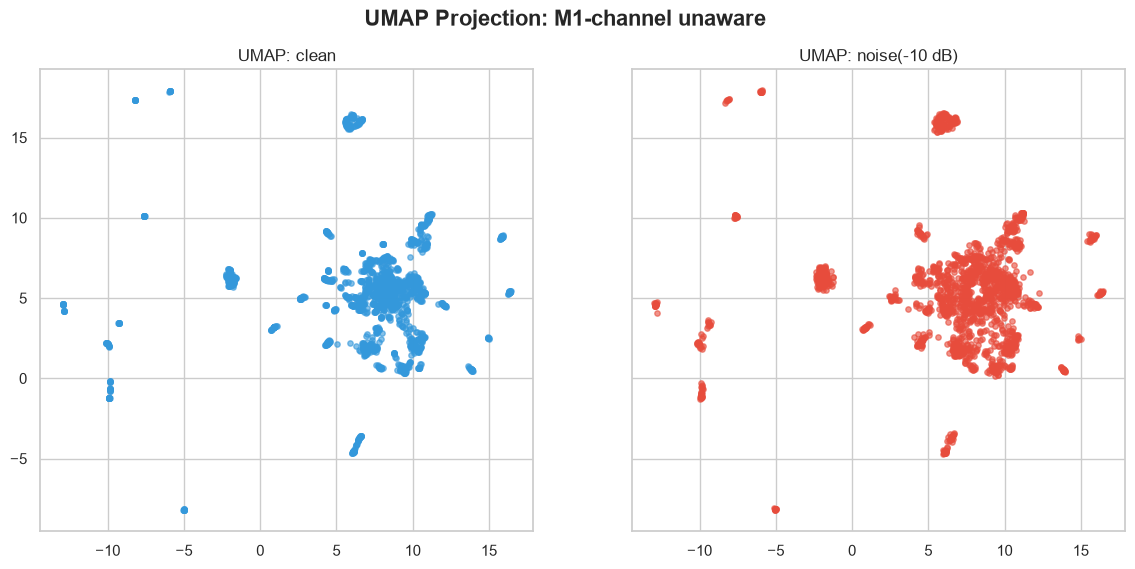

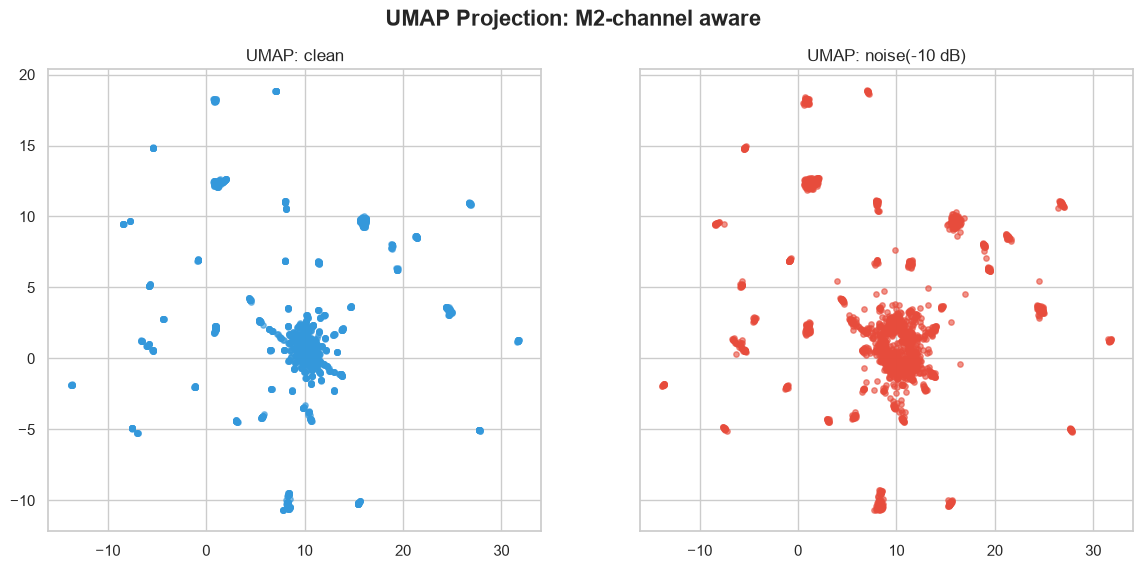

In [28]:
try:
    import umap
    def plot_umap_projection(pristine, noisy, title):
        reducer = umap.UMAP(n_components=2, random_state=42)
        clean_2d = reducer.fit_transform(pristine.cpu().numpy())
        noisy_2d = reducer.transform(noisy.cpu().numpy())
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
        axes[0].scatter(clean_2d[:, 0], clean_2d[:, 1], alpha=0.6, c='#3498db', s=15)
        axes[0].set_title("UMAP: clean")
        axes[1].scatter(noisy_2d[:, 0], noisy_2d[:, 1], alpha=0.6, c='#e74c3c', s=15)
        axes[1].set_title("UMAP: noise(-10 dB)")
        fig.suptitle(title, fontsize=16, fontweight='bold')
        plt.show()

    plot_umap_projection(h1_pristine, h1_noisy, "UMAP Projection: M1-channel unaware")
    if model2_available:
        plot_umap_projection(h2_pristine, h2_noisy, "UMAP Projection: M2-channel aware")
except ImportError:
    print("install umap")

### Negation Rule
Does noise bridge the gap between opposites . tracking cosine similarity between contradictory sentences

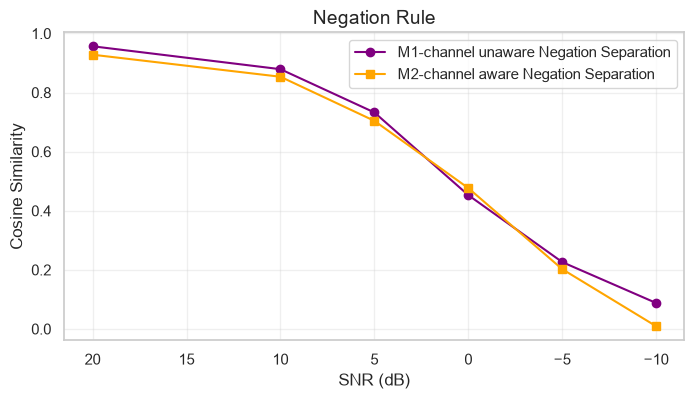

In [30]:
def test_negation_survival(model, snr_sweep):
    s1, s2 = "i like aadz for who she is", "i hate aadz for who she is"
    t1 = tokenizer(s1, return_tensors="pt").to(device)
    t2 = tokenizer(s2, return_tensors="pt").to(device)
    cos = torch.nn.CosineSimilarity(dim=1)
    results = []
    with torch.no_grad():
        h1 = model.t5.encoder(**t1).last_hidden_state.mean(dim=1)
        h2 = model.t5.encoder(**t2).last_hidden_state.mean(dim=1)
        for snr in snr_sweep:
            n1 = model.channel(h1, snr_db_override=snr)
            n2 = model.channel(h2, snr_db_override=snr)
            results.append(cos(n1, n2).item())
    return results

snrs = [20.0, 10.0, 5.0, 0.0, -5.0, -10.0]
neg_m1 = test_negation_survival(model1, snrs)
plt.figure(figsize=(8,4))
plt.plot(snrs, neg_m1, marker='o', color='purple', label="M1-channel unaware Negation Separation")
if model2_available:
    neg_m2 = test_negation_survival(model2, snrs)
    plt.plot(snrs, neg_m2, marker='s', color='orange', label="M2-channel aware Negation Separation")
plt.gca().invert_xaxis()
plt.title("Negation Rule", fontsize=14)
plt.xlabel("SNR (dB)")
plt.ylabel("Cosine Similarity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

###PCA analysis on semantic structure survival upon noise
We compress the manifold to $k$ dimensions, reconstruct it, and measure semantic fidelity , the M2 channel aware model performs much better

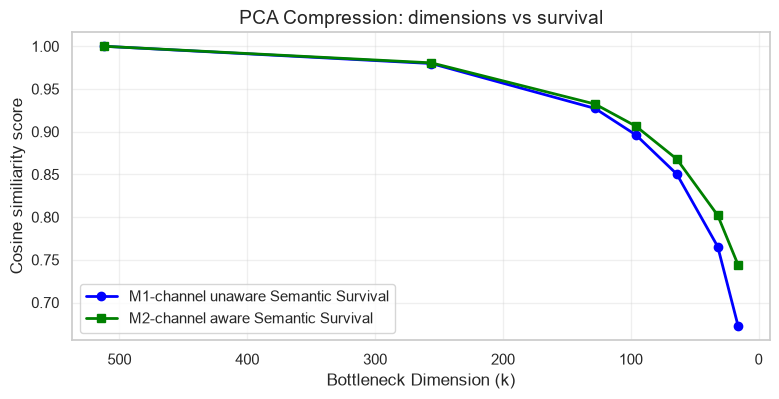

In [31]:
def semantic_structure_survival(pristine, k_vals):
    numpy_data = pristine.cpu().numpy()
    sims = []
    for k in k_vals:
        pca = PCA(n_components=k)
        compressed = pca.fit_transform(numpy_data)
        reconstructed = pca.inverse_transform(compressed)
        c = F.cosine_similarity(pristine, torch.tensor(reconstructed).to(device), dim=1).mean().item()
        sims.append(c)
    return sims

sims_m1 = semantic_structure_survival(h1_pristine, k_sweep)
plt.figure(figsize=(9, 4))
plt.plot(k_sweep, sims_m1, marker='o', lw=2, color='blue', label="M1-channel unaware Semantic Survival")
if model2_available:
    sims_m2 = semantic_structure_survival(h2_pristine, k_sweep)
    plt.plot(k_sweep, sims_m2, marker='s', lw=2, color='green', label="M2-channel aware Semantic Survival")
plt.gca().invert_xaxis()
plt.title("PCA Compression: dimensions vs survival", fontsize=14)
plt.xlabel("Bottleneck Dimension (k)")
plt.ylabel("Cosine similiarity score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 21. PCA Pipeline
Visualizing exactly how many principal components are required to retain 95% of semantic variance.

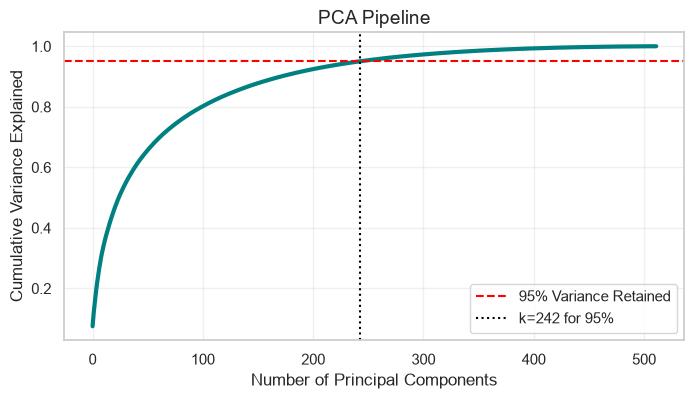

In [33]:
pca_full = PCA().fit(h1_pristine.cpu().numpy())
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(8, 4))
plt.plot(cum_var, lw=3, color='teal')
plt.axhline(0.95, color='red', linestyle='--', label="95% Variance Retained")
k_95 = np.argmax(cum_var >= 0.95)
plt.axvline(k_95, color='black', linestyle=':', label=f"k={k_95} for 95%")
plt.title("PCA Pipeline", fontsize=14)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()